In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [7]:
df = pd.read_csv(r"C:\Users\HP\Downloads\creditcard.csv\creditcard.csv")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
print("=== CLASS DISTRIBUTION ===")
print(df['Class'].value_counts())

print("\n=== FRAUD RATE ===")
fraud_rate = (df['Class'].sum() / len(df)) * 100
print(f"Fraud Rate: {fraud_rate:.2f}%")

print("\n=== AMOUNT STATS ===")
print(df['Amount'].describe())

=== CLASS DISTRIBUTION ===
Class
0    284315
1       492
Name: count, dtype: int64

=== FRAUD RATE ===
Fraud Rate: 0.17%

=== AMOUNT STATS ===
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


In [11]:
# Hour column
df['Hour'] = (df['Time'] // 3600) % 24

# Risk Level
def risk_label(amount):
    if amount < 100:
        return 'Low Risk'
    elif amount < 1000:
        return 'Medium Risk'
    else:
        return 'High Risk'

df['Risk_Level'] = df['Amount'].apply(risk_label)

# Transaction Size
def txn_size(amount):
    if amount == 0:
        return 'Zero Amount'
    elif amount < 50:
        return 'Small'
    elif amount < 500:
        return 'Medium'
    else:
        return 'Large'

df['Txn_Size'] = df['Amount'].apply(txn_size)

print("✅ New columns added!")
print(df[['Hour', 'Risk_Level', 'Txn_Size']].head())

✅ New columns added!
   Hour   Risk_Level Txn_Size
0   0.0  Medium Risk   Medium
1   0.0     Low Risk    Small
2   0.0  Medium Risk   Medium
3   0.0  Medium Risk   Medium
4   0.0     Low Risk   Medium


In [13]:
total = len(df)
fraud = df['Class'].sum()
legit = total - fraud
fraud_rate = (fraud / total) * 100
avg_fraud_amt = df[df['Class']==1]['Amount'].mean()
total_fraud_amt = df[df['Class']==1]['Amount'].sum()
max_fraud_amt = df[df['Class']==1]['Amount'].max()

print("=" * 45)
print(f"  Total Transactions : {total:,}")
print(f"  Fraud Cases        : {fraud:,}")
print(f"  Legit Cases        : {legit:,}")
print(f"  Fraud Rate         : {fraud_rate:.2f}%")
print(f"  Avg Fraud Amount   : ${avg_fraud_amt:.2f}")
print(f"  Total Fraud Amount : ${total_fraud_amt:.2f}")
print(f"  Max Fraud Amount   : ${max_fraud_amt:.2f}")
print("=" * 45)

  Total Transactions : 284,807
  Fraud Cases        : 492
  Legit Cases        : 284,315
  Fraud Rate         : 0.17%
  Avg Fraud Amount   : $122.21
  Total Fraud Amount : $60127.97
  Max Fraud Amount   : $2125.87


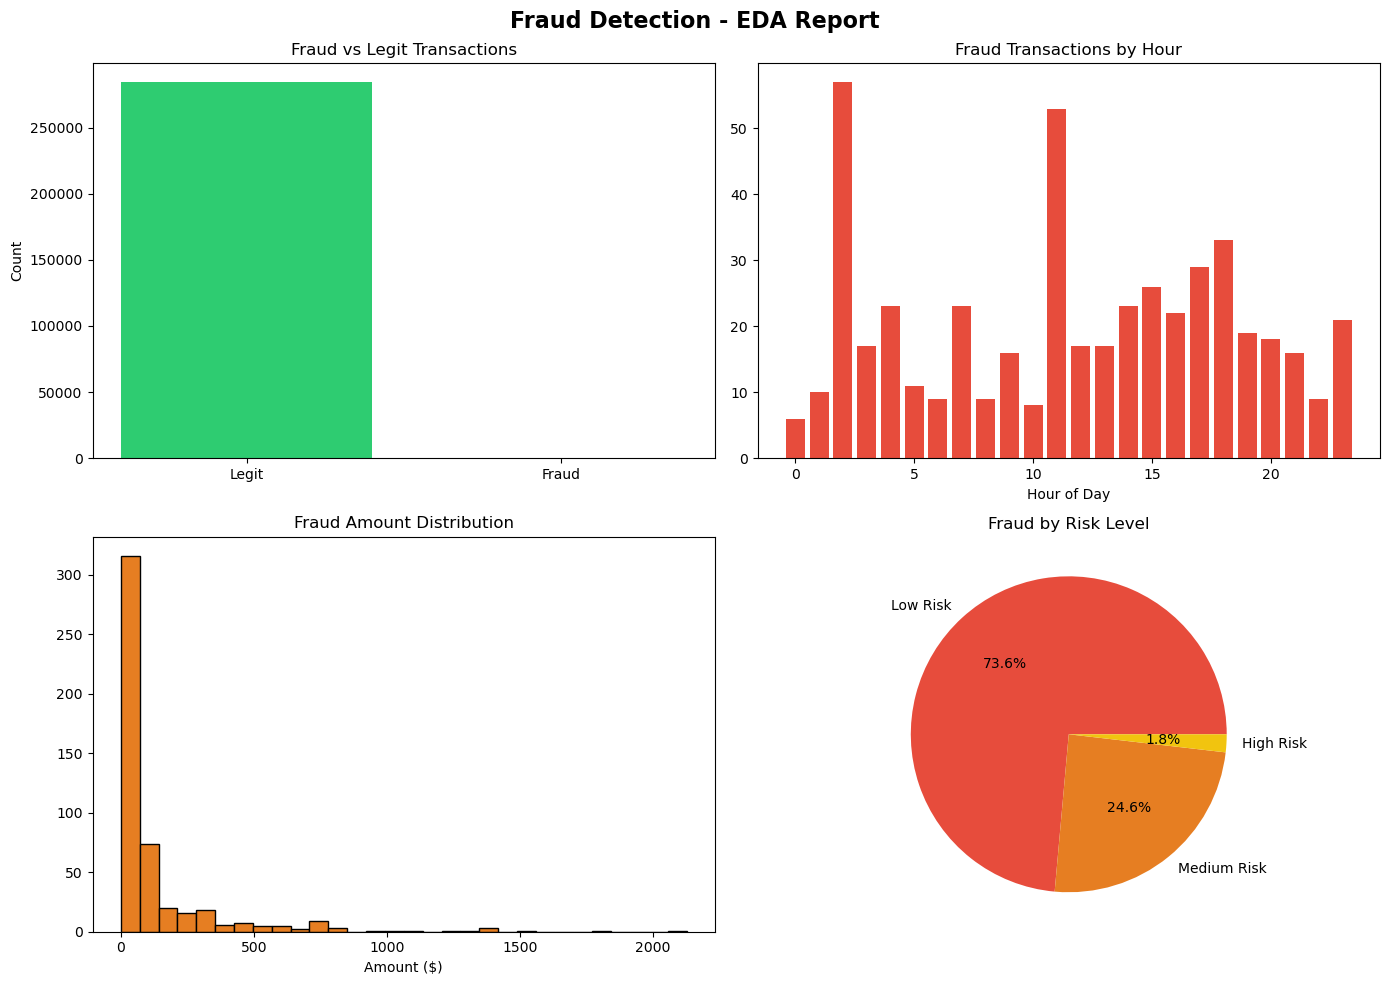

✅ Charts saved!


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Fraud Detection - EDA Report', fontsize=16, fontweight='bold')

# Chart 1 - Fraud vs Legit
axes[0,0].bar(['Legit', 'Fraud'], [legit, fraud], color=['#2ecc71','#e74c3c'])
axes[0,0].set_title('Fraud vs Legit Transactions')
axes[0,0].set_ylabel('Count')

# Chart 2 - Fraud by Hour
fraud_hour = df[df['Class']==1].groupby('Hour')['Class'].count()
axes[0,1].bar(fraud_hour.index, fraud_hour.values, color='#e74c3c')
axes[0,1].set_title('Fraud Transactions by Hour')
axes[0,1].set_xlabel('Hour of Day')

# Chart 3 - Amount Distribution
axes[1,0].hist(df[df['Class']==1]['Amount'], bins=30, color='#e67e22', edgecolor='black')
axes[1,0].set_title('Fraud Amount Distribution')
axes[1,0].set_xlabel('Amount ($)')

# Chart 4 - Risk Level Pie
risk_fraud = df[df['Class']==1]['Risk_Level'].value_counts()
axes[1,1].pie(risk_fraud.values, labels=risk_fraud.index,
              autopct='%1.1f%%', colors=['#e74c3c','#e67e22','#f1c40f'])
axes[1,1].set_title('Fraud by Risk Level')

plt.tight_layout()
plt.savefig(r"C:\Users\HP\Downloads\fraud_eda_charts.png", dpi=150)
plt.show()
print("✅ Charts saved!")

In [17]:
df_export = df[['Time', 'Hour', 'Amount', 'Class', 'Risk_Level', 'Txn_Size']]
df_export.to_csv(r"C:\Users\HP\Downloads\fraud_powerbi.csv", index=False)

print("✅ File exported successfully!")
print(f"Rows: {len(df_export):,}")
print(f"Columns: {df_export.columns.tolist()}")

✅ File exported successfully!
Rows: 284,807
Columns: ['Time', 'Hour', 'Amount', 'Class', 'Risk_Level', 'Txn_Size']
